In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# -----------------------------
# Model: dF(t,T) = F(t,T)[σ1 e^{-a1(T-t)} dW1(t) + σ2 e^{-a2(T-t)} dW2(t)]
# -----------------------------
# Step 1: Generate synthetic forward curve data (or load historical data)
np.random.seed(1)
finalT = 720
dates = np.arange(0, finalT, 1)  #finalT days horizon simulation
last_tenor = 750
initial_tenors = np.arange(30, last_tenor, 30)  # forward maturities in days
n_tenors = len(initial_tenors)
F0 = np.array([40]*n_tenors)  # initial forward price in €/MWh
n_paths = 1000

# Parameters (to be estimated in real case)
sigma0, sigma1 = 0.4, 0.3
a0, a1 = 0, 1
rho = 0.5

# Correlated Brownian motions
dt = 1/365
cov_matrix = np.array([[1, rho], [rho, 1]])
L = np.linalg.cholesky(cov_matrix)

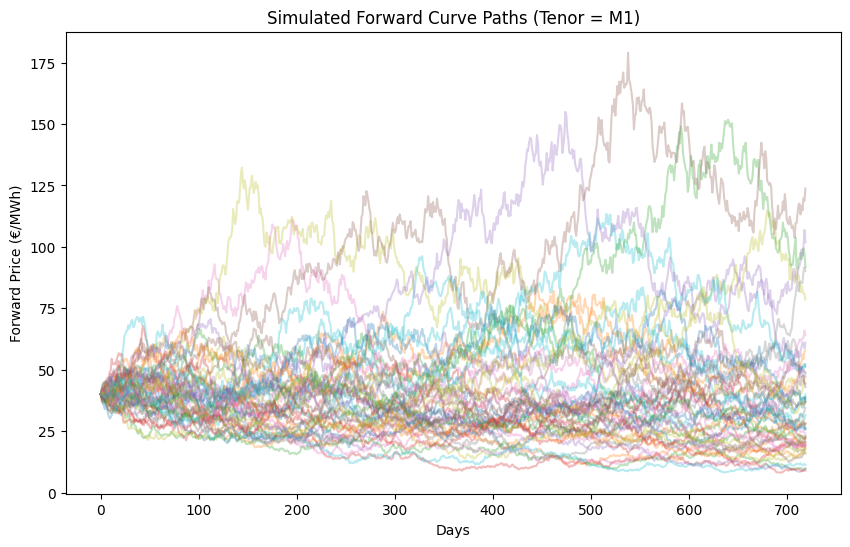

In [68]:
# Step 2: Simulate forward curves
def simulate_forward_curve(F0, dates, initial_tenors, sigma0, sigma1, a0, a1, n_paths):
    n_steps = len(dates)
    n_tenors = len(initial_tenors)
    F_paths = np.zeros((n_paths, n_steps, n_tenors))
    F_paths[:, 0, :] = F0
    tenors_matrix = np.zeros((n_steps, n_tenors))
    tenors_matrix[0, :] = initial_tenors

    for i in range(1, n_steps):
        dW = np.dot(L, np.random.normal(size=(2, n_paths))) * np.sqrt(dt)
        add_back_tenor = False
        for j in range(n_tenors):
            tau = max(initial_tenors[j] - i, 1) / 365
            if initial_tenors[j] - i == 1:
                add_back_tenor = True
            vol_term = sigma0 * np.exp(-a0 * tau) * dW[0] + sigma1 * np.exp(-a1 * tau) * dW[1]
            F_paths[:, i, j] = F_paths[:, i-1, j] * (1 + vol_term)
        if add_back_tenor:
            initial_tenors = np.append(initial_tenors[1:], [last_tenor])
            F_paths[:,i:, :-1] = F_paths[:, i:, 1:]
    return F_paths

F_sim = simulate_forward_curve(F0, dates, initial_tenors, sigma0, sigma1, a0, a1, n_paths)

# Step 3: Plot sample paths for one tenor
plt.figure(figsize=(10, 6))
for k in range(50):  # plot 50 paths
    plt.plot(dates, F_sim[k, :, 0], alpha=0.3)
plt.title("Simulated Forward Curve Paths (Tenor = M1)")
plt.xlabel("Days")
plt.ylabel("Forward Price (€/MWh)")
plt.show()

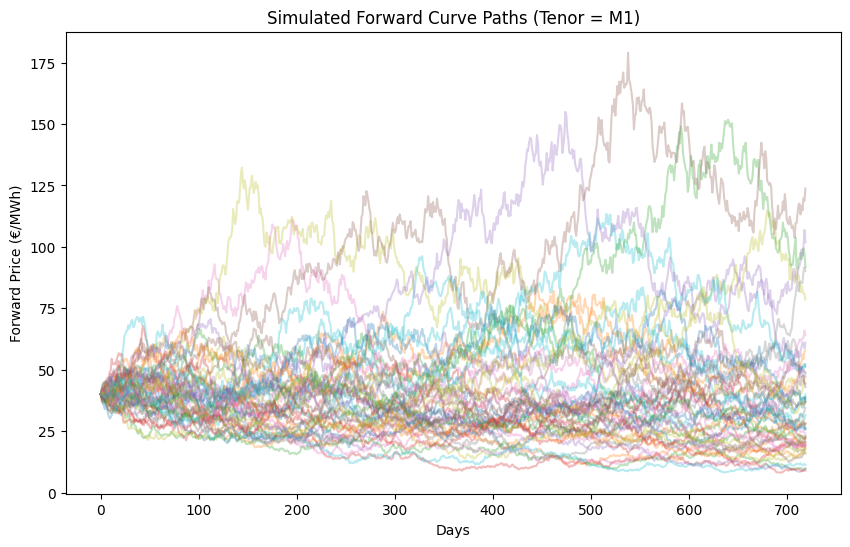

In [4]:
def calculate_volatility_all_paths(prices, trading_days_per_year=365):

    # Step 1: Calculate Logarithmic Returns
    # log_return = ln(P_i / P_{i-1})
    log_returns = np.log(prices[:, 1:, :] / prices[:, :-1, :])
    daily_volatility = log_returns.std(1)
    annualized_volatility = daily_volatility * np.sqrt(trading_days_per_year)
    return annualized_volatility

vol_matrix_from_sim = calculate_volatility_all_paths(F_sim)
vol_test = vol_matrix_from_sim[20, 0]
print(f"Annualized Volatility (based on 252 trading days): {vol_test:.4f} ({vol_test*100:.2f}%)")
vol_matrix_from_sim.mean(0)

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(15, 8))
axes = axes.flatten()
# 1. Create the figure and the axes for the plot
for i, ax in enumerate(axes):
    vols_Mi = vol_matrix_from_sim[:, i*3]
    # plt.figure(figsize=(10, 6))
    ax.hist(vols_Mi, bins=20, color='#1f77b4', edgecolor='black', alpha=0.7, rwidth=0.9)
    # 3. Add labels and title for clarity
    ax.set_title(f"M{i*3} vols from simulation", fontsize=16, fontweight='bold')
    # plt.xlabel("Value Range (Bins)", fontsize=12)
    # plt.ylabel("Frequency (Count)", fontsize=12)

    # 4. Add a grid for easier reading of the values
    # plt.grid(axis='y', alpha=0.5, linestyle='--')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # rect leaves space for the suptitle

# 7. Display the plot
plt.show()

Annualized Volatility (based on 252 trading days): 0.5974 (59.74%)


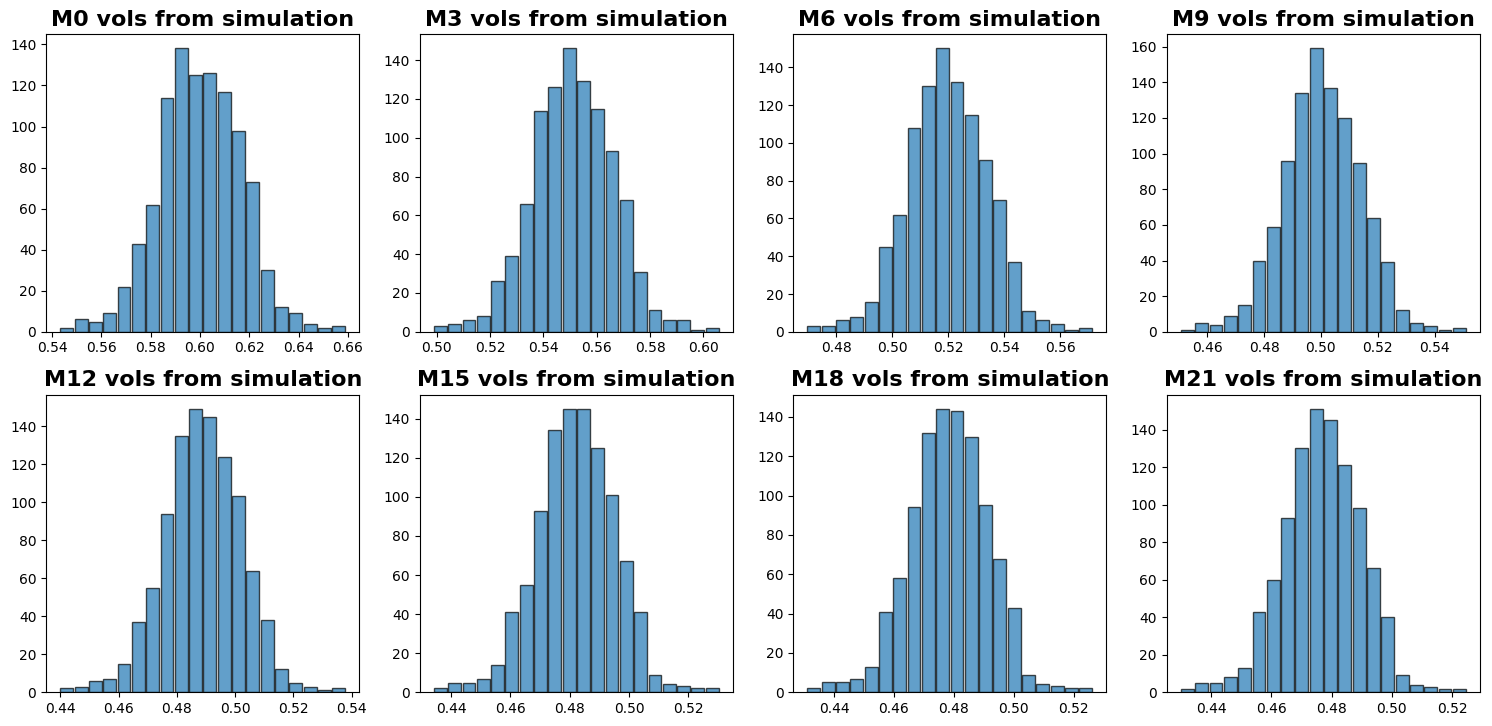

In [6]:
vol_matrix_from_sim.shape